In [1]:
import numpy as np
import scipy.stats as sps

import glob as glob
import pickle
import sys
import re

import torch
from ili.utils.ndes_pt import LampeEnsemble
from ili.validation.metrics import PlotSinglePosterior, PosteriorCoverage
from torch_geometric.data import Data as PYGData

import matplotlib.pyplot as plt
import ili

2026-04-29 18:33:44.107155: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1777502024.128376   17337 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1777502024.134667   17337 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-04-29 18:33:44.157614: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [2]:
# Need these things for the model to even unpickle the posterior pickle
sys.path.insert(0, '/home/puehlengt/ltu-ili/notebooks/ambe_fits')

'''
# 3 parameter model
# from train_deepset import DeepSet, GraphData, apt_param_config
PREBUILT_PATH = '/home/puehlengt/appletree/notebooks/pyg_dataset_raw_3params.pt'
RAW_PATH      = '/home/puehlengt/appletree/notebooks/harvested_testsims_3params.npy'
#'''

# 6 parameter model
from train_hybrid5_deepset_6params import Hybrid5DeepSet, PyGBatchWrapper, GraphData, make_summary, apt_param_config
PREBUILT_PATH = '/home/puehlengt/appletree/notebooks/pyg_dataset_raw_6params.pt'
RAW_PATH      = '/home/puehlengt/appletree/notebooks/harvested_testsims_6params.npy'

In [3]:
ultimate_fbase = '/home/puehlengt/ltu-ili/notebooks/ambe_fits/6_param_trained_models/deepset_sweep/'

#fchkpt = '50000totalsamples_hybrid5_deepset_nsf_h64_t5_emb_hs32_hl2_lr0.0003_ReduceLROnPlateau'
#fchkpt = '50000totalsamples_hybrid5_deepset_nsf_h64_t5_emb_hs32_hl3_lr0.0003_ReduceLROnPlateau'
#fchkpt = '50000totalsamples_hybrid5_deepset_nsf_h64_t5_emb_hs64_hl2_lr0.0003_ReduceLROnPlateau'
fchkpt = '50000totalsamples_hybrid5_deepset_nsf_h64_t5_emb_hs64_hl3_lr0.0003_ReduceLROnPlateau'

#MODE = 'final'      # 'final' = load from run's own posterior.pkl
MODE = 'checkpoint' # 'checkpoint' = load architecture from 500-sample pkl, override weights from checkpoint
SELECT_EPOCH = 500  # only used if MODE == 'checkpoint'

In [4]:
import ili
from torch.distributions.transforms import AffineTransform
import ili.utils.distributions_pt as dpt
from ili.utils.ndes_pt import LampeNPE

out_dir = f'{ultimate_fbase}/{fchkpt}'  # always the actual run dir
fbase = out_dir  # used by PlotSinglePosterior and PosteriorCoverage

# Parse arch from run name
_hs = int(re.search(r'hs(\d+)', fchkpt).group(1))
_hl = int(re.search(r'hl(\d+)', fchkpt).group(1))
_hf = int(re.search(r'_h(\d+)_', fchkpt).group(1))
_nt = int(re.search(r'_t(\d+)_', fchkpt).group(1))

# Load norm_stats to reconstruct theta_transform and prior
with open(f'{out_dir}/norm_stats.pkl', 'rb') as f:
    _ns = pickle.load(f)

_theta_transform = AffineTransform(
    loc=_ns['theta_mean'], scale=_ns['theta_std'], event_dim=1)

_means = [p['prior_args'].get('mean', p['init_mean']) for p in apt_param_config.values()]
_stds  = [p['prior_args'].get('std',  p['init_std'])  for p in apt_param_config.values()]
_lows  = [p['allowed_range'][0] for p in apt_param_config.values()]
_highs = [p['allowed_range'][1] for p in apt_param_config.values()]
_prior = dpt.IndependentTruncatedNormal(loc=_means, scale=_stds, low=_lows, high=_highs)

_embedding = Hybrid5DeepSet(
    in_channels=2, hidden_layers=_hl, hidden_channels=_hs, out_channels=8)

# load_nde_lampe needs one batch to infer embedding output dim — provide a minimal dummy
from torch_geometric.data import Batch as PYGBatch
_dummy_pyg = PYGData(x=torch.zeros(10, 2), y=torch.zeros(1, 6), summary=torch.zeros(1, 5))
_dummy_batch = PyGBatchWrapper(PYGBatch.from_data_list([_dummy_pyg]))
_dummy_loader = [(_dummy_batch, torch.zeros(1, 6))]

_factory = ili.utils.load_nde_lampe(
    model='nsf', hidden_features=_hf, num_transforms=_nt,
    embedding_net=_embedding, x_normalize=False, theta_normalize=False)[0]
base_model = _factory(_dummy_loader, _prior)
base_model.theta_transform = _theta_transform

if MODE == 'final':
    with open(f'{out_dir}/posterior.pkl', 'rb') as f:
        ensemble = pickle.load(f)
    base_model = ensemble.posteriors[0]
    print(f'Loaded final model from {out_dir}/posterior.pkl')

else:  # checkpoint
    path_bag = glob.glob(f'{out_dir}/checkpoint_epoch*.pt')
    path_bag.sort(key=lambda p: int(re.search(r'epoch(\d+)', p).group(1)))
    epochs_available = [int(re.search(r'epoch(\d+)', p).group(1)) for p in path_bag]
    print('Available epochs:', epochs_available)

    ckpt_path = path_bag[epochs_available.index(SELECT_EPOCH)]
    base_model.load_state_dict(torch.load(ckpt_path, map_location='cpu'))
    print(f'Loaded checkpoint epoch {SELECT_EPOCH}: {ckpt_path}')

base_model.eval()

Available epochs: [100, 200, 300, 400, 500]
Loaded checkpoint epoch 500: /home/puehlengt/ltu-ili/notebooks/ambe_fits/6_param_trained_models/deepset_sweep//50000totalsamples_hybrid5_deepset_nsf_h64_t5_emb_hs64_hl3_lr0.0003_ReduceLROnPlateau/checkpoint_epoch500.pt


/tmp/ipykernel_17337/380126227.py:56: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  base_model.load_state_dict(torch.load(ckpt_path, map_location='cpu'))


LampeNPE(
  (nde): NPE(
    (flow): NSF(
      (transform): LazyComposedTransform(
        (0): MaskedAutoregressiveTransform(
          (base): MonotonicRQSTransform(bins=8)
          (order): [0, 1, 2, 3, 4, 5]
          (hyper): MaskedMLP(
            (0): MaskedLinear(in_features=19, out_features=64, bias=True)
            (1): ReLU()
            (2): MaskedLinear(in_features=64, out_features=64, bias=True)
            (3): ReLU()
            (4): MaskedLinear(in_features=64, out_features=138, bias=True)
          )
        )
        (1): MaskedAutoregressiveTransform(
          (base): MonotonicRQSTransform(bins=8)
          (order): [5, 4, 3, 2, 1, 0]
          (hyper): MaskedMLP(
            (0): MaskedLinear(in_features=19, out_features=64, bias=True)
            (1): ReLU()
            (2): MaskedLinear(in_features=64, out_features=64, bias=True)
            (3): ReLU()
            (4): MaskedLinear(in_features=64, out_features=138, bias=True)
          )
        )
        (2)

In [5]:
# (unused — model loading is handled in the cell above)

In [6]:
# Load test data
N_OBS = 1000

num_samples = int(re.search(r'(\d+)totalsamples', fchkpt).group(1))

# Load norm stats (from training data) for test set normalization
with open(f'{ultimate_fbase}/{fchkpt}/norm_stats.pkl', 'rb') as f:
    norm_stats = pickle.load(f)

# Load test data
if torch.os.path.exists(PREBUILT_PATH):
    full = torch.load(PREBUILT_PATH)
    raw_test = list(full[num_samples:num_samples + N_OBS])
else:
    aa = np.load(RAW_PATH, allow_pickle=True).item()
    param_bag, events_bag = aa['param_bag'], aa['events_bag']
    raw_test = [
        PYGData(
            x=torch.tensor(events_bag[i].T),
            y=torch.tensor([v for v in param_bag[i].values()]).reshape(1, -1),
        )
        for i in range(num_samples, num_samples + N_OBS)
    ]

# Compute and z-norm summary stats for test data (6-param model only)
all_summaries_test = np.stack([make_summary(d) for d in raw_test])
summary_norm_test  = torch.tensor(
    (all_summaries_test - norm_stats['summary_mean']) / norm_stats['summary_std'],
    dtype=torch.float32
)

test_graph = GraphData(raw_test, norm_stats['events_mean'], norm_stats['events_std'], summary_norm_test)

# param_names in data order — everything (theta tensors, posterior samples) is in data order
_data_param_order = list(np.load(RAW_PATH, allow_pickle=True).item()['param_bag'][0].keys())
param_names = _data_param_order

theta_test = np.array([d.y.numpy().flatten() for d in raw_test])
print(f'num_samples={num_samples}, test set size={len(raw_test)}')
print(f'param order: {param_names}')

/tmp/ipykernel_17337/596121804.py:12: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  full = torch.load(PREBUILT_PATH)


num_samples=50000, test set size=1000
param order: ['g1', 'g2', 'alpha', 'beta', 'epsilon', 'ambe_nr_rate']


In [7]:
posterior = LampeEnsemble(posteriors=[base_model],
                          weights=torch.tensor([1.0])) # weights of the different NN in the ensemble

## Marginal posteriors

INFO:root:Sampling models with [1000] samples each.
Drawing 1000 posterior samples: 100%|██████████| 1000/1000 [00:00<00:00, 2578.17it/s]


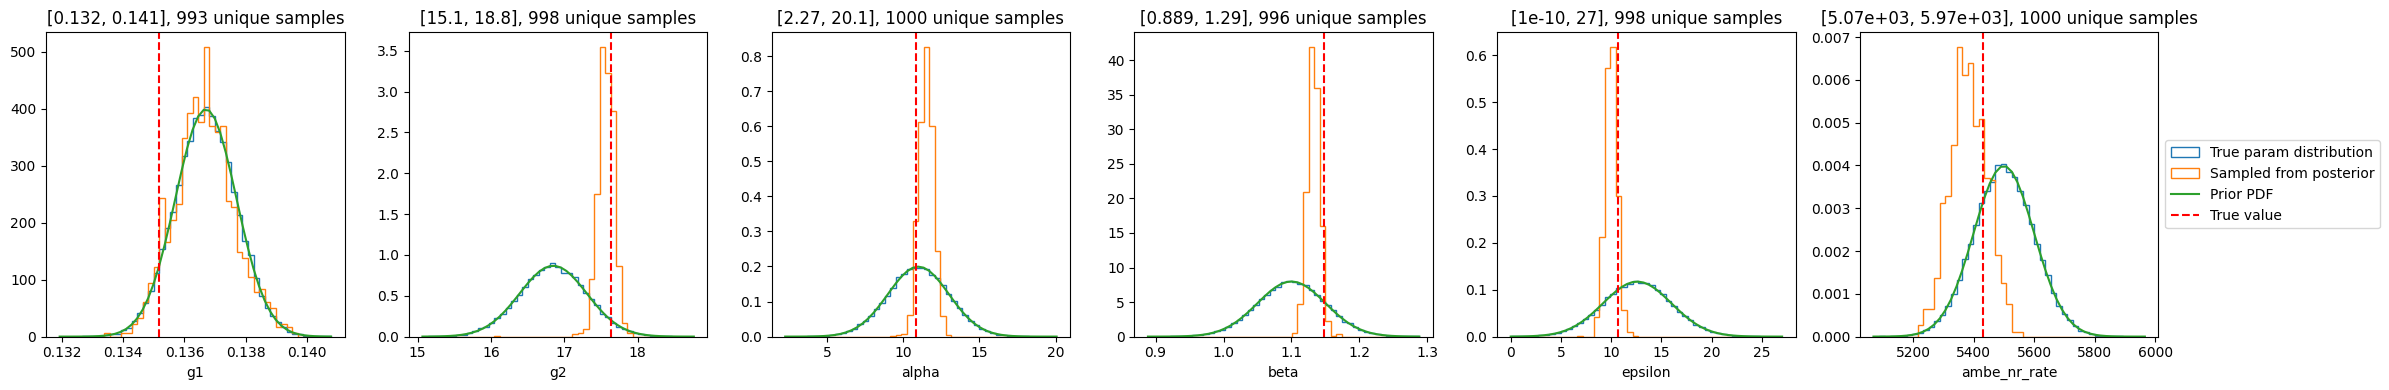

In [8]:
OBS_IDX = 0  # change to look at a different test observation

x_obs = test_graph[OBS_IDX]
y_true = theta_test[OBS_IDX]

torch.manual_seed(1234)
samples = posterior.sample((1000,), x_obs).cpu().numpy()

theta_train = np.array([d.y.numpy().flatten() for d in full[:num_samples]])

n_params = len(param_names)
n_cols   = min(6, n_params)
n_rows   = int(np.ceil(n_params / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 4, n_rows * 4))
axes = np.array(axes).reshape(n_rows, n_cols)

for _ii, key in enumerate(param_names):
    ax = axes[_ii // n_cols, _ii % n_cols]
    val = apt_param_config[key]

    zzz = theta_train[:, _ii]
    zzmin, zzmax = zzz.min(), zzz.max()
    zzxx = np.linspace(zzmin, zzmax, 50)
    zzmean = val['prior_args'].get('mean', val['init_mean'])
    zzstd  = val['prior_args'].get('std',  val['init_std'])

    ax.hist(zzz, bins=zzxx, density=True, histtype='step', label='True param distribution')
    ax.hist(samples[:, _ii], bins=zzxx, density=True, histtype='step', label='Sampled from posterior')
    if zzstd > 0:
        ax.plot(zzxx, sps.norm.pdf(zzxx, loc=zzmean, scale=zzstd), label='Prior PDF')
    ax.axvline(y_true[_ii], color='red', linestyle='--', label='True value')
    ax.set_title(f'[{zzmin:.3g}, {zzmax:.3g}], {len(np.unique(samples[:, _ii]))} unique samples')
    ax.set_xlabel(key)

axes.flat[n_params - 1].legend(loc='center left', bbox_to_anchor=(1., 0.5))

for _ii in range(n_params, n_rows * n_cols):
    axes.flat[_ii].set_visible(False)

plt.tight_layout()
fig.savefig(f'{out_dir}/marginal_posteriors_obs{OBS_IDX}.png', dpi=150, bbox_inches='tight')
plt.show()

INFO:root:Sampling models with [1000] samples each.
Drawing 1000 posterior samples: 100%|██████████| 1000/1000 [00:00<00:00, 8157.17it/s]
INFO:root:Saving single posterior plot to /home/puehlengt/ltu-ili/notebooks/ambe_fits/6_param_trained_models/deepset_sweep/50000totalsamples_hybrid5_deepset_nsf_h64_t5_emb_hs64_hl3_lr0.0003_ReduceLROnPlateau/plot_single_posterior.jpg...


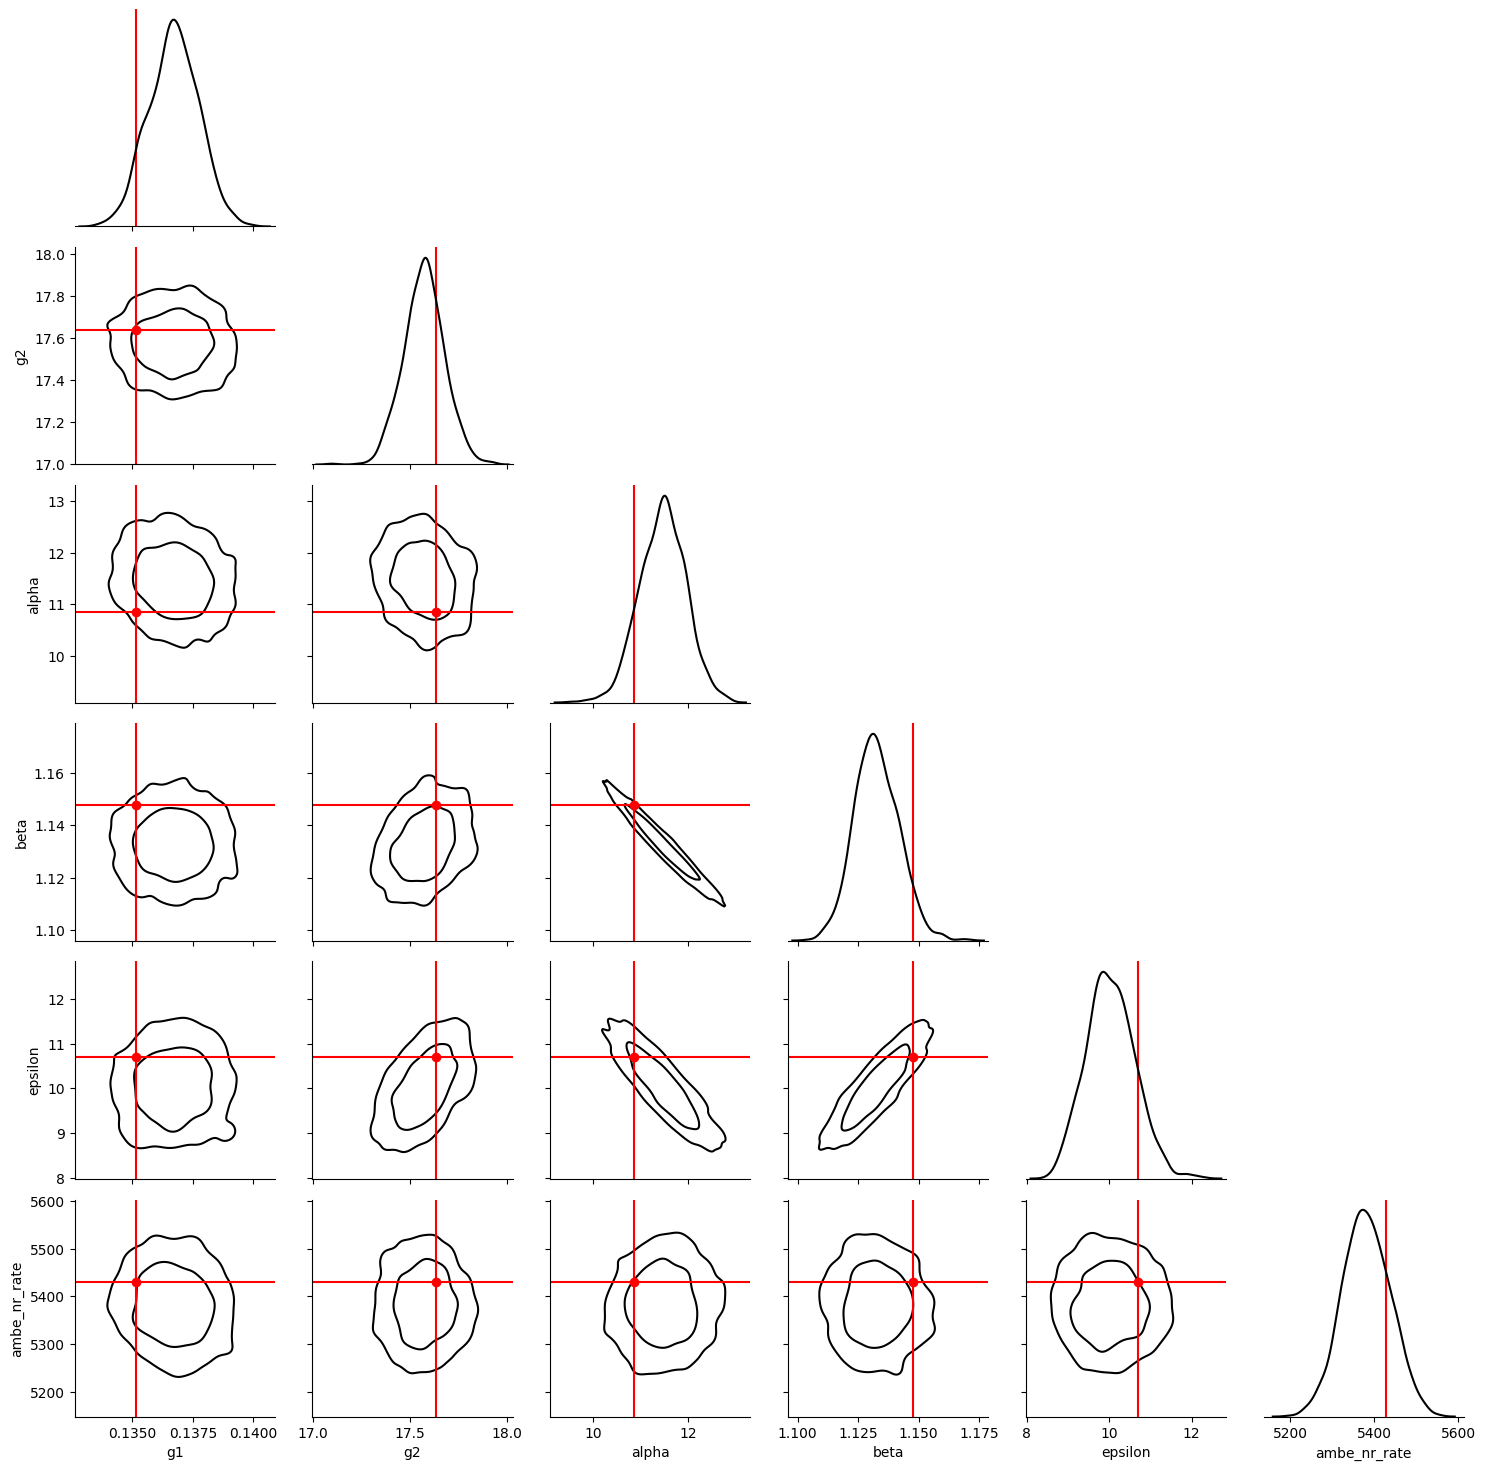

In [9]:
metric = PlotSinglePosterior(
    num_samples=1000, sample_method='direct',
    labels=param_names, out_dir=fbase,
)
fig = metric(posterior=posterior, x_obs=x_obs, theta_fid=y_true)

100%|██████████| 1000/1000 [01:54<00:00,  8.72it/s]
INFO:root:Saving coverage plot to /home/puehlengt/ltu-ili/notebooks/ambe_fits/6_param_trained_models/deepset_sweep/50000totalsamples_hybrid5_deepset_nsf_h64_t5_emb_hs64_hl3_lr0.0003_ReduceLROnPlateau/plot_coverage.jpg...
INFO:root:Saving ranks histogram to /home/puehlengt/ltu-ili/notebooks/ambe_fits/6_param_trained_models/deepset_sweep/50000totalsamples_hybrid5_deepset_nsf_h64_t5_emb_hs64_hl3_lr0.0003_ReduceLROnPlateau/ranks_histogram.jpg...
100%|██████████| 100/100 [00:14<00:00,  6.86it/s]


[<Figure size 2400x400 with 6 Axes>,
 <Figure size 1800x400 with 6 Axes>,
 <Figure size 2400x400 with 6 Axes>,
 <Figure size 400x400 with 1 Axes>]

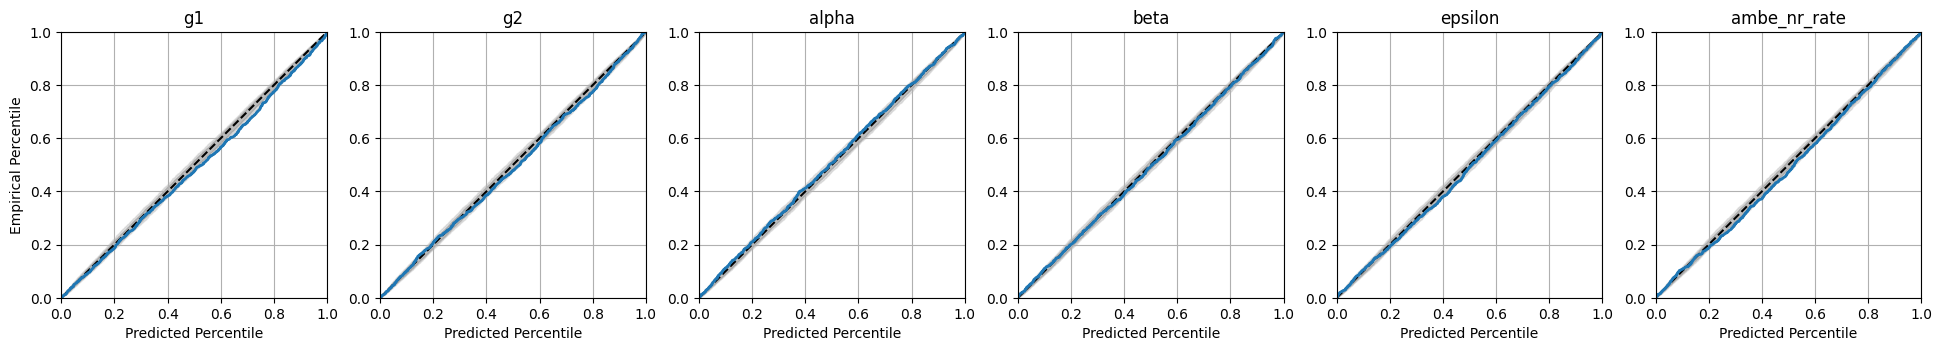

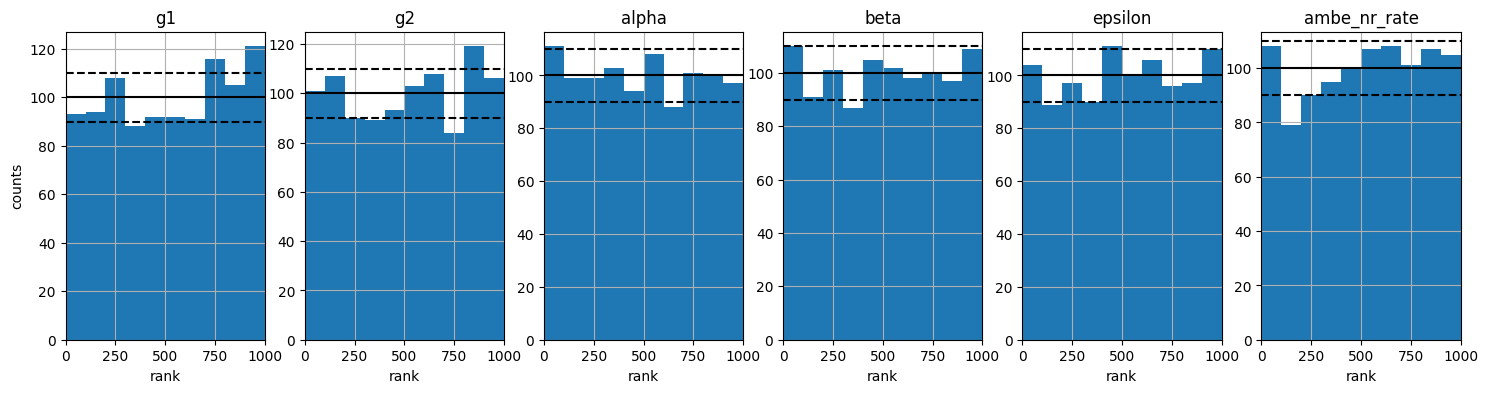

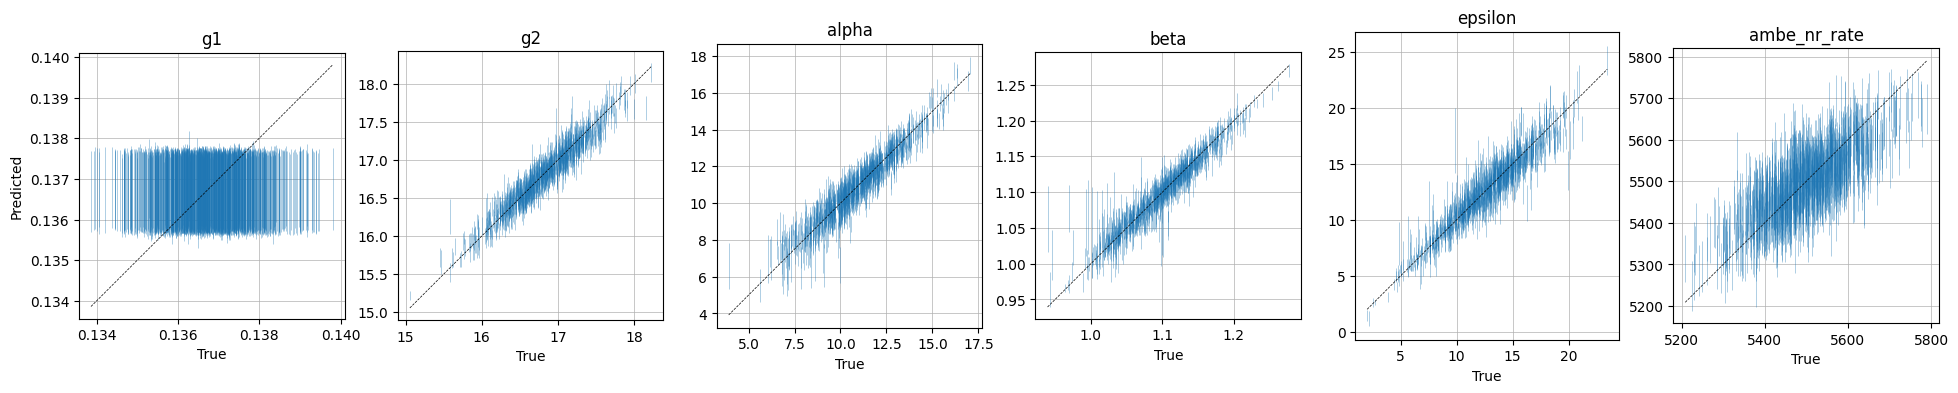

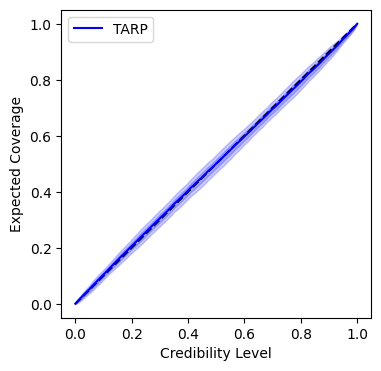

In [10]:
metric = PosteriorCoverage(
    num_samples=1000, sample_method='direct',
    out_dir=fbase, labels=param_names,
    plot_list=['coverage', # PP plots
               'predictions', # pred vs truth
               'tarp', # posterior coverage??
               'histogram'], # uhhh
    save_samples=False,
)
metric(posterior=posterior, x=test_graph, theta=theta_test)

In [11]:
fchkpt

'50000totalsamples_hybrid5_deepset_nsf_h64_t5_emb_hs64_hl3_lr0.0003_ReduceLROnPlateau'